# California Housing Dataset — Complete Preprocessing Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler    

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('housing.csv')

print(f'Dataset shape: {df.shape}')
display(df.head())

Dataset shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
print('Shape:', df.shape)
    
print('\nColumn names:')
print(df.columns.tolist())

print('\nData types:')
display(df.dtypes.to_frame('dtype'))

print('\nDataset information:')
df.info()

Shape: (20640, 10)

Column names:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Data types:


,dtype
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,str



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
    
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
    
missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
})

display(missing_summary[missing_summary['missing_count'] > 0])

,missing_count,missing_percent
total_bedrooms,207,1.002907


In [7]:
duplicate_count = df.duplicated().sum()
print(f'Duplicate rows: {duplicate_count}')

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Duplicates removed.')
else:
    print('No duplicate rows found.')

Duplicate rows: 0
No duplicate rows found.


In [8]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_columns:
    print(f'\n{col}:')
    print(df[col].value_counts(dropna=False))


ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


C:\Users\irukagae\AppData\Local\Temp\ipykernel_13520\3843523172.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()


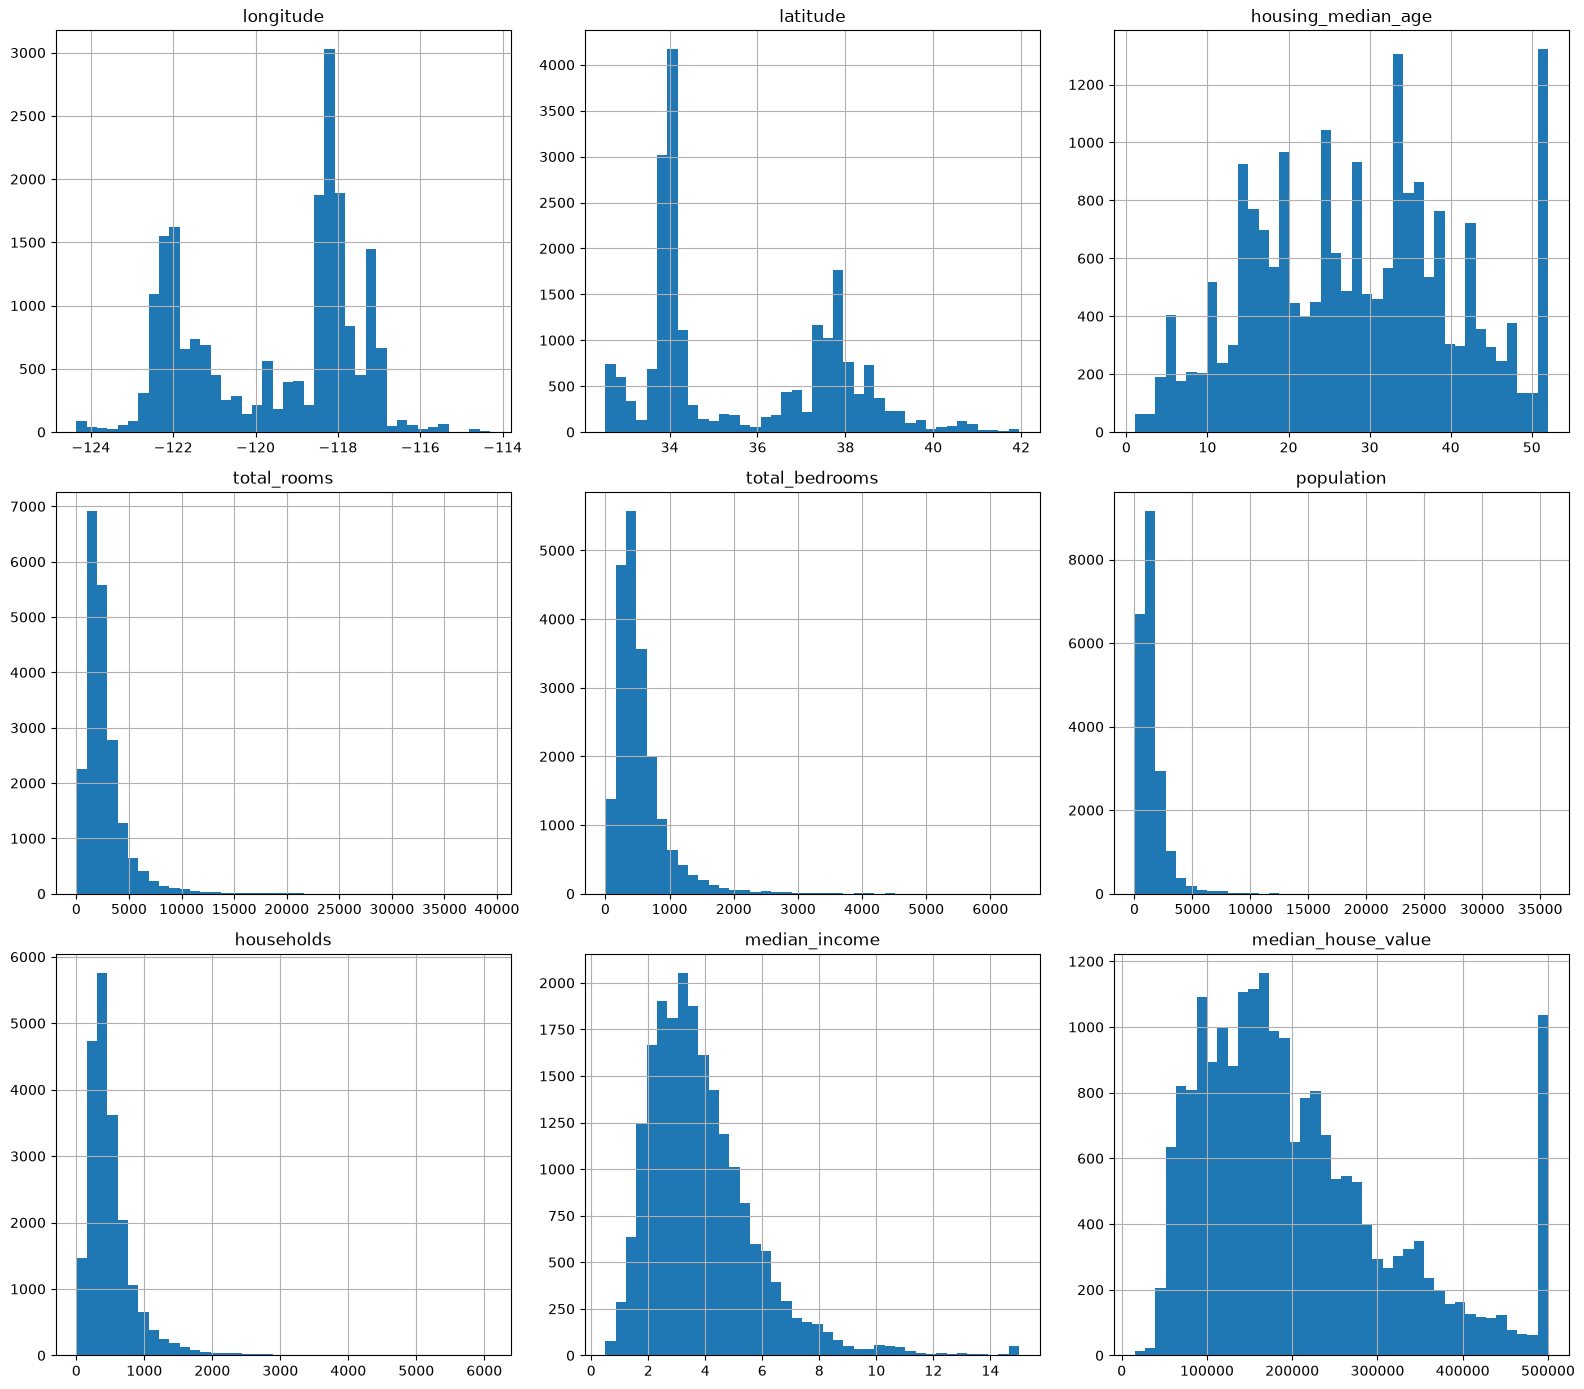

In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

df[numeric_columns].hist(figsize=(16, 14), bins=40)
plt.tight_layout()
plt.show()

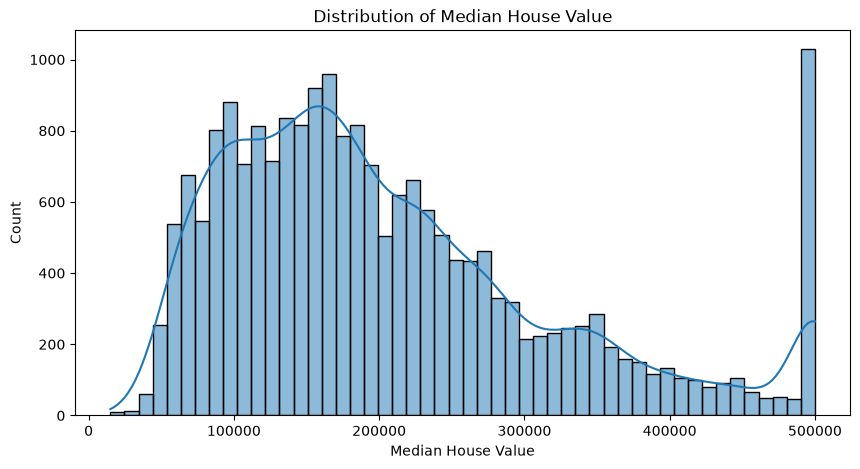

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64


In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.show()

print(df['median_house_value'].describe())

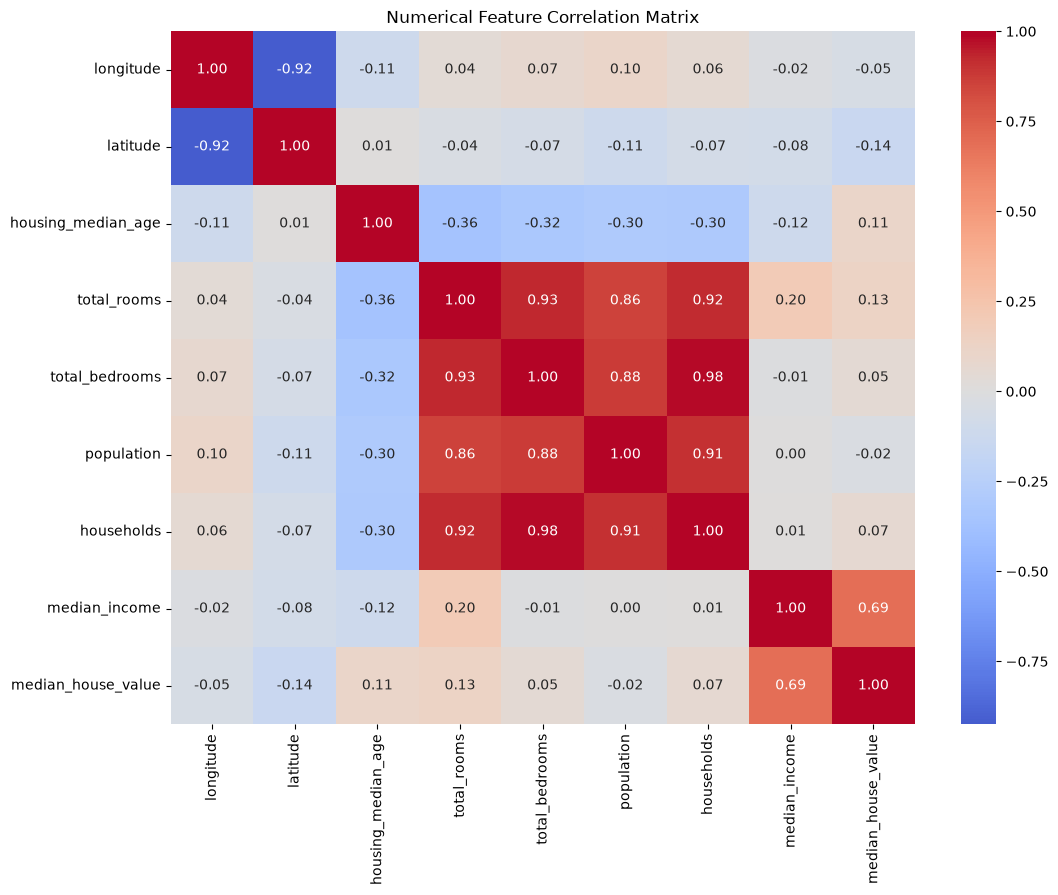

Correlation with target:


,correlation
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


In [11]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numerical Feature Correlation Matrix')
plt.show()

print('Correlation with target:')
display(correlation_matrix['median_house_value'].sort_values(ascending=False).to_frame('correlation'))

In [12]:
housing = df.copy()

# Create income categories for stratified sampling.
housing['income_cat'] = pd.cut(
    housing['median_income'],
    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5]
)

train_set, test_set = train_test_split(
    housing,
    test_size=0.20,
    random_state=42,
    stratify=housing['income_cat']
)

train_set = train_set.drop(columns=['income_cat'])
test_set = test_set.drop(columns=['income_cat'])

print('Training set shape:', train_set.shape)
print('Test set shape:', test_set.shape)

Training set shape: (16512, 10)
Test set shape: (4128, 10)


In [13]:
target_column = 'median_house_value'

X_train = train_set.drop(columns=[target_column]).copy()
y_train = train_set[target_column].copy()

X_test = test_set.drop(columns=[target_column]).copy()
y_test = test_set[target_column].copy()

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test :', X_test.shape)
print('y_test :', y_test.shape)

X_train: (16512, 9)
y_train: (16512,)
X_test : (4128, 9)
y_test : (4128,)


In [14]:
def add_features(X):
    X = X.copy()
    X['rooms_per_household'] = X['total_rooms'] / X['households']
    X['bedrooms_per_room'] = X['total_bedrooms'] / X['total_rooms']
    X['population_per_household'] = X['population'] / X['households']
    return X

X_train_engineered = add_features(X_train)
display(X_train_engineered.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,5.485836,0.205784,3.168555
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,6.927083,0.160714,2.623698
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND,5.393333,0.191595,2.223333
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,3.886128,0.276505,1.859213
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,6.096552,0.182692,3.167241


In [15]:
X_train_engineered = add_features(X_train)

num_features = X_train_engineered.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train_engineered.select_dtypes(include=['object', 'category']).columns.tolist()

print('Numerical features:')
print(num_features)

print('\nCategorical features:')
print(cat_features)

Numerical features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

Categorical features:
['ocean_proximity']


C:\Users\irukagae\AppData\Local\Temp\ipykernel_13520\1216459331.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train_engineered.select_dtypes(include=['object', 'category']).columns.tolist()


In [16]:
from sklearn.preprocessing import FunctionTransformer

def feature_engineering(X):
    X = X.copy()
    X['rooms_per_household'] = X['total_rooms'] / X['households']
    X['bedrooms_per_room'] = X['total_bedrooms'] / X['total_rooms']
    X['population_per_household'] = X['population'] / X['households']
    return X

feature_adder = FunctionTransformer(feature_engineering, validate=False)

# Determine columns after feature engineering.
X_train_with_features = feature_engineering(X_train)
    
num_features = X_train_with_features.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train_with_features.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

full_preprocessing_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_adder),
    ('preprocessor', preprocessor)
])

print('Preprocessing pipeline created successfully.')

Preprocessing pipeline created successfully.


C:\Users\irukagae\AppData\Local\Temp\ipykernel_13520\791541927.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train_with_features.select_dtypes(include=['object', 'category']).columns.tolist()


In [17]:
X_train_processed = full_preprocessing_pipeline.fit_transform(X_train)
X_test_processed = full_preprocessing_pipeline.transform(X_test)

print('Processed X_train shape:', X_train_processed.shape)
print('Processed X_test shape :', X_test_processed.shape)

Processed X_train shape: (16512, 16)
Processed X_test shape : (4128, 16)


In [18]:
feature_names = full_preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()

print(f'Number of processed features: {len(feature_names)}')
print('\nFirst 20 feature names:')
print(feature_names[:20])

Number of processed features: 16

First 20 feature names:
['num__longitude' 'num__latitude' 'num__housing_median_age'
 'num__total_rooms' 'num__total_bedrooms' 'num__population'
 'num__households' 'num__median_income' 'num__rooms_per_household'
 'num__bedrooms_per_room' 'num__population_per_household'
 'cat__ocean_proximity_<1H OCEAN' 'cat__ocean_proximity_INLAND'
 'cat__ocean_proximity_ISLAND' 'cat__ocean_proximity_NEAR BAY'
 'cat__ocean_proximity_NEAR OCEAN']


In [19]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

display(X_train_processed_df.head())

,num__longitude,num__latitude,num__housing_median_age,num__total_rooms,num__total_bedrooms,num__population,num__households,num__median_income,num__rooms_per_household,num__bedrooms_per_room,num__population_per_household,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN
12655,-0.941350,1.347438,0.027564,0.584777,0.640371,0.732602,0.556286,-0.893647,0.017395,-0.122484,0.006223,0.0,1.0,0.0,0.0,0.0
15502,1.171782,-1.192440,-1.722018,1.261467,0.781561,0.533612,0.721318,1.292168,0.569256,-0.911663,-0.040811,0.0,0.0,0.0,0.0,1.0
2908,0.267581,-0.125972,1.220460,-0.469773,-0.545138,-0.674675,-0.524407,-0.525434,-0.018024,-0.370939,-0.075371,0.0,1.0,0.0,0.0,0.0
14053,1.221738,-1.351474,-0.370069,-0.348652,-0.036367,-0.467617,-0.037297,-0.865929,-0.595140,1.115873,-0.106803,0.0,0.0,0.0,0.0,1.0
20496,0.437431,-0.635818,-0.131489,0.427179,0.272790,0.374060,0.220898,0.325752,0.251241,-0.526821,0.006109,1.0,0.0,0.0,0.0,0.0


In [20]:
print('Missing values in processed training data:', np.isnan(X_train_processed).sum())
print('Missing values in processed test data:', np.isnan(X_test_processed).sum())

print('\nApproximate means of first numerical features:')
display(X_train_processed_df.iloc[:, :len(num_features)].mean().head(10))

print('\nApproximate standard deviations of first numerical features:')
display(X_train_processed_df.iloc[:, :len(num_features)].std().head(10))

Missing values in processed training data: 0
Missing values in processed test data: 0

Approximate means of first numerical features:


num__longitude              1.844347e-15
num__latitude               3.605213e-15
num__housing_median_age     8.778508e-17
num__total_rooms           -1.721276e-17
num__total_bedrooms        -1.385627e-16
num__population            -1.936436e-18
num__households            -1.118829e-17
num__median_income         -1.110223e-16
num__rooms_per_household   -6.799040e-17
num__bedrooms_per_room      4.285977e-16
dtype: float64


Approximate standard deviations of first numerical features:


num__longitude              1.00003
num__latitude               1.00003
num__housing_median_age     1.00003
num__total_rooms            1.00003
num__total_bedrooms         1.00003
num__population             1.00003
num__households             1.00003
num__median_income          1.00003
num__rooms_per_household    1.00003
num__bedrooms_per_room      1.00003
dtype: float64

In [21]:
train_processed = X_train_processed_df.copy()
train_processed[target_column] = y_train

test_processed = X_test_processed_df.copy()
test_processed[target_column] = y_test

print('Final processed training data:', train_processed.shape)
print('Final processed test data:', test_processed.shape)
    

Final processed training data: (16512, 17)
Final processed test data: (4128, 17)


In [22]:
train_processed.to_csv('housing_train_preprocessed.csv', index=False)
test_processed.to_csv('housing_test_preprocessed.csv', index=False)

print('Saved: housing_train_preprocessed.csv')
print('Saved: housing_test_preprocessed.csv')

Saved: housing_train_preprocessed.csv
Saved: housing_test_preprocessed.csv
